## Desarrollo tarea HW Sesión 6

Felipe López Vergara

In [66]:
import yfinance as yf
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model
from scipy.stats import t
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.stats as stats 

## 1. Aprendizaje no Supervisado — Segmentación de Clientes para Otorgamiento de Tarjetas de Crédito

Considere el dataset creditSIM.xlsx que contiene información de clientes de un banco. El objetivo es construir perfiles o clusters de clientes de modo que, mediante estrategias de campañas de marketing, se pueda decidir a quién otorgar tarjetas de crédito. El dataset contiene las siguientes variables:

ID: Número de cliente.
AgnosDirec: Años que el cliente lleva viviendo en la misma dirección.
AgnosEmpleo: Años de antigüedad del cliente en el empleo.
DeudaExt: Deuda del cliente externa al banco.
DeudaInt: Deuda del cliente en el banco (por ejemplo, otros créditos).
Edad: Edad del cliente.
Ingreso/Ingreso2: Ingreso del cliente (recopilados de dos fuentes diferentes).
Nacionalidad: Nacionalidad del cliente.
NivelEdu: Nivel educacional del cliente.
VarObj: Variable objetivo — si el cliente cae en bancarrota al recibir el crédito (S) o no (N).

⚠️ Regla del ejercicio: VarObj no puede usarse como input del proceso de clustering (sería leakage, ya que en producción no se conoce el comportamiento futuro del cliente al momento de aprobar la tarjeta). Su único uso permitido es como variable de validación externa en la Sección 1.6.

### 1.1 Auditoría y Preprocesamiento de Datos

(a) Reporte tipos de datos, cardinalidad de las variables categóricas, porcentaje de valores nulos por columna y estadística descriptiva de las variables numéricas. Justifique una estrategia de imputación (o eliminación) para los nulos encontrados — no use dropna() sin antes cuantificar cuánta información se pierde.

## 2. Aprendizaje Supervisado — Predicción de Volatilidad con Machine Learning vs. Modelos GARCH

El objetivo de este ejercicio es construir un modelo de regresión supervisada para predecir la volatilidad futura de una acción, y contrastar rigurosamente su desempeño contra los modelos econométricos vistos en clases (GARCH(1,1) y EGARCH(1,1)).

### 2.1 Descarga y Construcción de Variables

(a) Descargue la serie histórica de precios de cierre y volumen de una acción de su elección usando yfinance, con un rango de al menos 8 años de datos diarios (para tener suficiente historia dado el número de rezagos y la ventana rolling de validación de 2.5).

In [2]:
# Descarga Serie de Precios de Google 

data = yf.download("GOOGL", start="2018-01-01", end="2025-12-31", progress = False)
data.columns = data.columns.droplevel(1)

In [3]:
print(data[-60:])

Price            Close        High         Low        Open    Volume
2025-10-06  249.940948  250.829225  244.102382  244.301988  28894700
2025-10-07  245.280075  249.950944  245.040553  247.785183  23181300
2025-10-08  244.142303  245.529588  243.343878  244.481651  21307100
2025-10-09  241.058334  244.282022  238.682977  243.992595  27892100
2025-10-10  236.108032  243.613336  235.379447  240.958527  33180300
2025-10-13  243.673233  244.022556  239.241916  239.740940  24995000
2025-10-14  244.970688  246.637425  240.040332  240.758927  22111600
2025-10-15  250.539795  251.617688  245.509644  246.767178  27007700
2025-10-16  250.968948  256.458193  249.611604  251.278341  27997200
2025-10-17  252.805359  253.723560  247.326074  250.270310  29671600
2025-10-20  256.049011  256.827487  253.733550  254.192658  22350200
2025-10-21  249.970901  254.382268  243.673211  254.242542  47312100
2025-10-22  251.198502  255.859365  248.803179  253.873261  35029400
2025-10-23  252.585785  254.541949

**(b)** Construya las siguientes variables:

**Retorno logarítmico diario:** $r_t =\log(\text{Close}_t /\text{Close}_{t-1})$

In [4]:
# Retorno logaritmico diario de los precios de cierre

data["Log_Retorno"] = np.log(data["Close"] / data["Close"].shift(1))

**Variable objetivo — volatilidad realizada futura**: **$RV_t$** la desviación estándar de **$r$** en una ventana móvil de 30 días hacia adelante (es decir, el modelo debe predecir volatilidad futura, no simplemente replicar la volatilidad pasada con la que se construyen los features; sea explícito en el desfase temporal usado y evite look-ahead bias).

In [5]:
# Variable Objetivo RV

window = 30
data["RV"] = (data["Log_Retorno"].shift(-1).rolling(window=window).std().shift(-(window-1)))

Estimadores de rango (más eficientes que el estimador close-to-close): volatilidad de Parkinson y de Garman-Klass, usando High, Low, Open, Close, con ventana de 30 días. Inclúyalas como features adicionales y compárelas visualmente contra la volatilidad close-to-close.

In [6]:
data['Volatilidad'] = data['Log_Retorno'].rolling(window = 30).std()

In [7]:
# Varianza diaria de Parkinson
log_hl = np.log(data['High'] / data['Low'])
parkinson_daily_var = (log_hl ** 2) / (4 * np.log(2))

# Volatilidad Parkinson (30 días)
data["Vol_Parkinson"] = np.sqrt(parkinson_daily_var.rolling(window=30).mean())

In [8]:
# Volatilidad de Garman-Klass

log_co = np.log(data['Close'] / data['Open'])
gk_daily_var = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)

# Volatilidad Garman-Klass (30 días)
data["Vol_GarmanKlass"] = np.sqrt(gk_daily_var.rolling(window=30).mean())

**Cambio porcentual del volumen:** $\displaystyle \text{Vol\_cambio}_t=\frac{\text{Volumen}_t-\text{Volumen}_{t-1}}{\text{Volumen}_{t-1}}$

In [9]:
# Cambio porcentual de volumen

data["Vol_cambio"] = data["Volume"].pct_change()

**Media móvil de precios** (20 días) y **distancia porcentual del precio respecto a su media móvil** (proxy de momentum/sobrecompra).

In [10]:
# Media móvil de precios

data["media_20"] = data["Close"].rolling(20).mean()

# Distancia entre el precio de cierre y la media móvil

data["Dist_MA20"] = ((data["Close"]-data["media_20"])/data["media_20"]) * 100

Skewness y kurtosis móvil de los retornos (ventana de 30 días) — motivadas por los hechos estilizados de colas pesadas vistos en clases.

In [11]:
# Skewness y Kurtosis de los retornos

data["Skew30"] = (data["Log_Retorno"].rolling(30).skew())
data["Kurt30"] = (data["Log_Retorno"].rolling(30).kurt())

**Rezagos:** para cada variable anterior, genere al menos 5 rezagos(Lag_Return_1, ..., Lag_Return_5, etc.).

In [12]:
# Generar rezagos para las variables
lags = 5
for lag in range(1, lags + 1):
    data[f'Lag_Return_{lag}'] = data['Log_Retorno'].shift(lag)
    data[f'Lag_RV_{lag}'] = data['RV'].shift(lag)
    data[f'Lag_Volatility_{lag}'] = data['Volatilidad'].shift(lag)
    data[f'Lag_Vol_Parkinson_{lag}'] = data['Vol_Parkinson'].shift(lag)
    data[f'Lag_Vol_Garman_Klass_{lag}'] = data['Vol_GarmanKlass'].shift(lag)
    data[f'Lag_Vol_cambio_{lag}'] = data['Vol_cambio'].shift(lag)
    data[f'Lag_Dist_MA20_{lag}'] = data['Dist_MA20'].shift(lag)
    data[f'Lag_Skew30_{lag}'] = data['Skew30'].shift(lag)
    data[f'Lag_Kurt30_{lag}'] = data['Kurt30'].shift(lag)

In [13]:
data.head()

Price,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,Vol_GarmanKlass,...,Lag_Kurt30_4,Lag_Return_5,Lag_RV_5,Lag_Volatility_5,Lag_Vol_Parkinson_5,Lag_Vol_Garman_Klass_5,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5
2018-01-02,53.188862,53.326145,52.188236,52.188236,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096317,54.323305,53.199768,53.224546,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,54.306450,54.718794,54.232112,54.372367,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Volatilidad implícita (VIX):** descargue la serie histórica del VIX y sincronícela con las fechas de su acción (atención a holidays/desfases de calendario entre mercados). Incluya el valor actual y al menos 5 rezagos.

In [14]:
# Descarga serie del VIX

vix = yf.download("^VIX",start="2018-01-01", end="2025-12-31", auto_adjust=True, progress=False)
vix.columns = vix.columns.get_level_values(0)
vix = vix[["Close"]].rename(columns={"Close": "VIX"})

# Sincronización con los datos de Google
data.index = pd.to_datetime(data.index)
vix.index = pd.to_datetime(vix.index)
data = data.join(vix, how="left")
data["VIX"] = data["VIX"].ffill()

# Crear rezagos del VIX

for lag in range(1, lags + 1):
    data[f'Lag_VIX_{lag}'] = data['VIX'].shift(lag)

In [15]:
data.head()

Price,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,Vol_GarmanKlass,...,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5,VIX,Lag_VIX_1,Lag_VIX_2,Lag_VIX_3,Lag_VIX_4,Lag_VIX_5
2018-01-02,53.188862,53.326145,52.188236,52.188236,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.77,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096317,54.323305,53.199768,53.224546,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.15,9.77,NaN,NaN,NaN,NaN
2018-01-04,54.306450,54.718794,54.232112,54.372367,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.15,9.77,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.22,9.15,9.77,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.52,9.22,9.22,9.15,9.77,NaN


**Variables macroeconómicas:** descargue y sincronice al menos tres variables macro (por ejemplo, tasa de interés de la Fed, inflación, tasa de desempleo, spread de tasas 10Y-2Y) desde FRED (vía pandas_datareader o fredapi), generando al menos 5 rezagos de cada una. Dado que estas series suelen publicarse con menor frecuencia (mensual), documente explícitamente el método de sincronización usado (ffill/asof) y por qué evita look-ahead bias.

In [16]:
# Descargar datos de la FRED

start = "2018-01-01"
end = "2025-12-31"

tasa_interes = pdr.DataReader("FEDFUNDS", "fred", start, end)
inflacion = pdr.DataReader("CPIAUCSL", "fred", start, end)
desempleo = pdr.DataReader("UNRATE", "fred", start, end)

In [17]:
# Unir variables macroecónimicas al dataset principal

macros = pd.concat([tasa_interes, inflacion, desempleo],axis=1)
data.index = pd.to_datetime(data.index)
macros.index = pd.to_datetime(macros.index)
data = data.join(macros, how="left")
data[["FEDFUNDS", "CPIAUCSL", "UNRATE"]] = (data[["FEDFUNDS", "CPIAUCSL", "UNRATE"]].ffill())

Se utiliza ffill() porque evita el "look-ahead bias" ya que siempre utiliza el último dato ya publicado y utiliza información publicada en el futuro.

In [18]:
# Crear 5 rezagos para cada variable macroeconómica

macro_vars = ["FEDFUNDS","CPIAUCSL","UNRATE"]

for var in macro_vars:
    for lag in range(1,6):
        data[f'Lag_{var}_{lag}'] = data[var].shift(lag)

data.head()

,Close,High,Low,Open,Volume,Log_Retorno,RV,Volatilidad,Vol_Parkinson,Vol_GarmanKlass,...,Lag_CPIAUCSL_1,Lag_CPIAUCSL_2,Lag_CPIAUCSL_3,Lag_CPIAUCSL_4,Lag_CPIAUCSL_5,Lag_UNRATE_1,Lag_UNRATE_2,Lag_UNRATE_3,Lag_UNRATE_4,Lag_UNRATE_5
2018-01-02,53.188862,53.326145,52.188236,52.188236,31766000,NaN,0.020540,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096317,54.323305,53.199768,53.224546,31318000,0.016917,0.020550,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,54.306450,54.718794,54.232112,54.372367,26052000,0.003877,0.020549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,55.026566,55.189621,54.605797,54.687572,30250000,0.013173,0.020448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,55.220840,55.466166,55.012192,55.061752,24644000,0.003524,0.020509,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.2 Análisis Exploratorio y Diagnóstico de Estacionariedad

**(a)** Aplique el test ADF (Augmented Dickey-Fuller) a la variable objetivo (RV_t) y a las variables macro utilizadas. ¿Alguna requiere diferenciación para ser estacionaria? Justifique si la usa en niveles, en diferencias, o en ambas formas como features separados.

In [19]:
def adf_test(serie, nombre):
    serie = serie.dropna()

    resultado = adfuller(serie)

    print(f"\nVariable: {nombre}")
    print(f"ADF Statistic : {resultado[0]:.4f}")
    print(f"p-value       : {resultado[1]:.4f}")

    if resultado[1] < 0.05:
        print("⇒ Se rechaza H0: la serie es estacionaria.")
    else:
        print("⇒ No se rechaza H0: la serie no es estacionaria.")

In [20]:
adf_test(data["RV"], "RV")


Variable: RV
ADF Statistic : -5.5594
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [21]:
adf_test(data["FEDFUNDS"], "tasa_interes")


Variable: tasa_interes
ADF Statistic : -0.6650
p-value       : 0.8556
⇒ No se rechaza H0: la serie no es estacionaria.


In [22]:
adf_test(data["CPIAUCSL"], "Inflación")


Variable: Inflación
ADF Statistic : 0.6102
p-value       : 0.9879
⇒ No se rechaza H0: la serie no es estacionaria.


In [23]:
adf_test(data["UNRATE"], "Desempleo")


Variable: Desempleo
ADF Statistic : -3.0171
p-value       : 0.0333
⇒ Se rechaza H0: la serie es estacionaria.


In [24]:
# Diferenciar tasa de interés e inflación 

data["FEDFUNDS_diff"] = data["FEDFUNDS"].diff()
data["CPIAUCSL_diff"] = data["CPIAUCSL"].diff()

In [25]:
#  Aplicar test ADF a las variables diferenciadas de tasa de interes e inflación

adf_test(data["FEDFUNDS_diff"], "tasa_interes_diferenciada")


Variable: tasa_interes_diferenciada
ADF Statistic : -44.5708
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [26]:
adf_test(data["CPIAUCSL_diff"], "inflación_diferenciada")


Variable: inflación_diferenciada
ADF Statistic : -45.2563
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


Se aplicó el test de Dickey-Fuller Aumentado (ADF) a la variable objetivo (RV) y a las variables macroeconómicas seleccionadas. La volatilidad realizada (RV) presentó un estadístico ADF de -5.5594 y un valor p inferior a 0.001, por lo que se rechazó la hipótesis nula de raíz unitaria, concluyendo que la serie es estacionaria. En consecuencia, se utilizó en niveles como variable objetivo del modelo.

Respecto de las variables macroeconómicas, la tasa de interés de la Reserva Federal (FEDFUNDS) y el índice de precios al consumidor (CPIAUCSL) no resultaron estacionarios en niveles, con valores p de 0.8556 y 0.9879, respectivamente. Por ello, ambas series fueron transformadas mediante una primera diferencia antes de incorporarlas al modelo, con el fin de eliminar la tendencia y cumplir el supuesto de estacionariedad. En cambio, la tasa de desempleo (UNRATE) presentó un valor p de 0.0333, por lo que se rechazó la hipótesis nula y se concluyó que la serie es estacionaria; en consecuencia, se utilizó en niveles.

**(b)** Grafique la matriz de correlación entre todos los features (o al menos entre las variables sin rezagar) y comente sobre potenciales problemas de multicolinealidad entre los rezagos de una misma variable — relevante especialmente para SVR, menos crítico para Random Forest.

In [27]:
# Dataframe de variables

variables = [
    "Log_Retorno",
    "RV",
    "Volatilidad",
    "Vol_Parkinson",
    "Vol_GarmanKlass",
    "Vol_cambio",
    "Dist_MA20",
    "Skew30",
    "Kurt30",
    "VIX",
    "FEDFUNDS_diff",
    "CPIAUCSL_diff",
    "UNRATE"
]

corr = data[variables].corr()

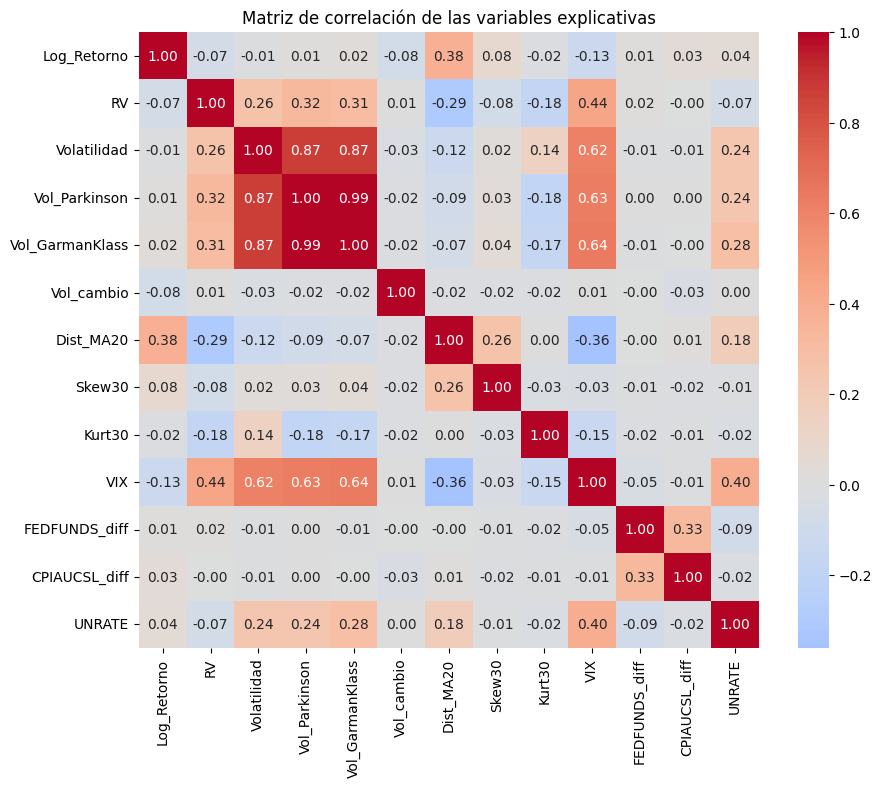

In [28]:
# Gráfico de matriz de correlación 

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables explicativas")
plt.show()

Los diferentes rezagos de una misma variable suelen estar altamente correlacionados debido a su dependencia temporal, lo que puede generar problemas de multicolinealidad. Esta redundancia introduce información repetida y puede afectar el rendimiento de modelos sensibles a variables correlacionadas, como Support Vector Regression (SVR), dificultando su estimación. En cambio, Random Forest es mucho menos afectado por este problema, ya que cada árbol se construye utilizando subconjuntos aleatorios de variables y la predicción final se obtiene al combinar los resultados de múltiples árboles, disminuyendo el impacto de las variables redundantes.

### 2.3 Preparación de Datos

**(a)** Elimine los valores nulos generados por los rezagos y ventanas móviles (inicio y fin de la muestra por la ventana forward).

In [30]:
# Eliminar valores nulos

data = data.dropna()

(b) Divida los datos en entrenamiento/validación/prueba respetando el **orden temporal** (por ejemplo, 70/15/15). Explique por qué un train_test_split aleatorio sería metodológicamente incorrecto en este contexto.

In [33]:
# Tamaño del conjunto de datos
n = len(data)

# Índices de corte (70% entrenamiento, 15% validación, 15% prueba)
train_end = int(0.70 * n)
val_end = int(0.85 * n)

# División temporal
train = data.iloc[:train_end]
valid = data.iloc[train_end:val_end]
test = data.iloc[val_end:]

print(f"Entrenamiento: {len(train)} observaciones ({len(train)/n:.1%})")
print(f"Validación:    {len(valid)} observaciones ({len(valid)/n:.1%})")
print(f"Prueba:        {len(test)} observaciones ({len(test)/n:.1%})")

# Variable objetivo
target = "RV"

# Variables predictoras
X_train = train.drop(columns=[target])
y_train = train[target]

X_valid = valid.drop(columns=[target])
y_valid = valid[target]

X_test = test.drop(columns=[target])
y_test = test[target]

Entrenamiento: 1361 observaciones (70.0%)
Validación:    292 observaciones (15.0%)
Prueba:        292 observaciones (15.0%)


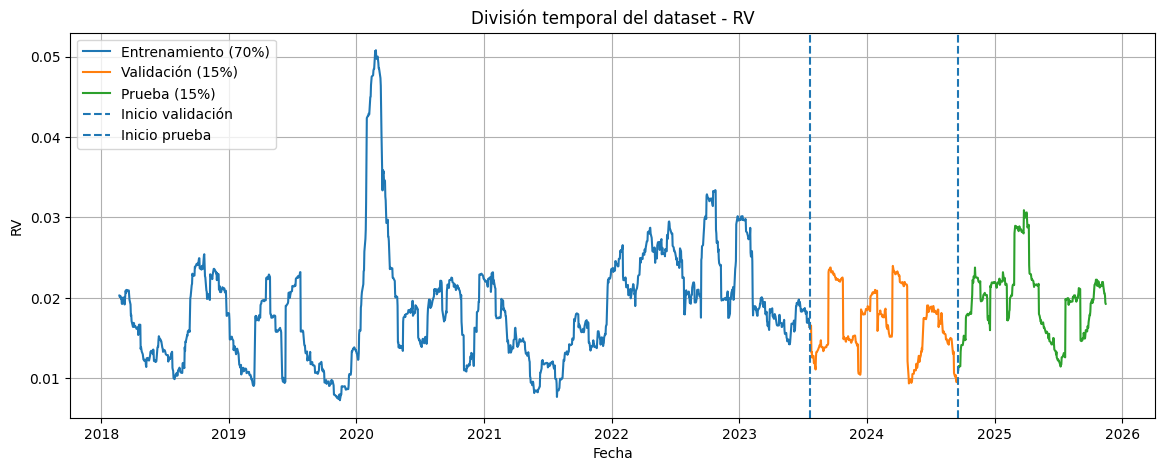

In [34]:
# Gráfico

plt.figure(figsize=(14,5))

plt.plot(y_train.index,y_train,label="Entrenamiento (70%)")
plt.plot(y_valid.index,y_valid,label="Validación (15%)")
plt.plot(y_test.index,y_test,label="Prueba (15%)")

# Líneas verticales de separación
plt.axvline(y_valid.index[0],linestyle="--",label="Inicio validación")
plt.axvline(y_test.index[0],linestyle="--",label="Inicio prueba")

plt.title(f"División temporal del dataset - {"RV"}")
plt.xlabel("Fecha")
plt.ylabel("RV")
plt.legend()
plt.grid(True)
plt.show()

Un train_test_split aleatorio sería metodológicamente incorrecto porque rompería la estructura temporal de los datos. En una serie financiera, las observaciones son secuenciales y la información disponible en un instante depende únicamente del pasado. Una división aleatoria mezclaría observaciones futuras con pasadas, permitiendo que el modelo se entrene con información que, en un escenario real de pronóstico, aún no estaría disponible (look-ahead bias). Esto produciría una evaluación demasiado optimista del desempeño del modelo y no reflejaría su capacidad para predecir datos verdaderamente futuros. Por ello, la partición debe realizarse respetando el orden cronológico: entrenamiento con las observaciones más antiguas, validación con un período posterior y prueba con las observaciones más recientes.

**(c)** Escale los features usando únicamente estadísticos calculados en el conjunto de entrenamiento (evite data leakage del conjunto de prueba hacia el scaler).

In [36]:
# Crear scaler de los features
scaler = StandardScaler()

# Ajustar SOLO con entrenamiento
scaler.fit(X_train)

# Transformar los datos de cada conjunto usando los estadísticos de entrenamiento
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_valid_scaled   = pd.DataFrame(scaler.transform(X_valid),   columns=X_valid.columns,   index=X_valid.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# Verificar que las dimensiones e índices se mantengan intactos
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_valid_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

X_train_scaled: (1361, 85)
X_val_scaled:   (292, 85)
X_test_scaled:  (292, 85)


### 2.4 Entrenamiento, Selección de Hiperparámetros y Modelos

(a) Entrene Random Forest y SVR (los modelos vistos en clases). Para la selección de hiperparámetros use TimeSeriesSplit (validación cruzada que respeta el orden temporal) combinado con GridSearchCV o RandomizedSearchCV — nunca k-fold estándar sobre series de tiempo. Reporte la grilla de hiperparámetros explorada para cada modelo.

In [37]:
# Configurar la validación cruzada respetando el orden temporal
tscv = TimeSeriesSplit(n_splits=5)

# ==========================================
# GRILLA DE HIPERPARÁMETROS: RANDOM FOREST
# ==========================================
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

# ==========================================
# GRILLA DE HIPERPARÁMETROS: SVR
# ==========================================
param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'epsilon': [0.0001, 0.0005, 0.001, 0.005]  # Ajustado al rango de RV (~0.02)
}

In [52]:
# ------------------------------------------
# Entrenamiento de Random Forest
# ------------------------------------------
rf_base = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Entrenar únicamente con los datos de entrenamiento escalados/procesados
grid_rf.fit(X_train_scaled, y_train)

# Mejor modelo rf
best_rf = grid_rf.best_estimator_

# ------------------------------------------
# Entrenamiento de SVR
# ------------------------------------------
svr_base = SVR(kernel='rbf')

grid_svr = GridSearchCV(
    estimator=svr_base,
    param_grid=param_grid_svr,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train_scaled, y_train)

# Mejor modelo svr
best_svr = grid_svr.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [53]:
print("==================================================")
print("REPORTE DE BÚSQUEDA DE HIPERPARÁMETROS")
print("==================================================\n")

print("--- 1. RANDOM FOREST ---")
print("Grilla explorada:")
for k, v in param_grid_rf.items():
    print(f"  - {k}: {v}")
print(f"\nMejores hiperparámetros encontrados:")
print(f"  {grid_rf.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_rf.best_score_:.6f}\n")

print("--- 2. SUPPORT VECTOR REGRESSION (SVR) ---")
print("Grilla explorada:")
for k, v in param_grid_svr.items():
    print(f"  - {k}: {v}")
print(f"\nMejores hiperparámetros encontrados:")
print(f"  {grid_svr.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_svr.best_score_:.6f}")

REPORTE DE BÚSQUEDA DE HIPERPARÁMETROS

--- 1. RANDOM FOREST ---
Grilla explorada:
  - n_estimators: [100]
  - max_depth: [3, 5, 10, None]
  - min_samples_split: [2, 5, 10]
  - min_samples_leaf: [1, 2, 4]
  - max_features: ['sqrt', 'log2', 1.0]

Mejores hiperparámetros encontrados:
  {'max_depth': 10, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Mejor MSE (Validación Cruzada): 0.000016

--- 2. SUPPORT VECTOR REGRESSION (SVR) ---
Grilla explorada:
  - C: [0.1, 1, 10, 100]
  - gamma: ['scale', 'auto', 0.001, 0.01, 0.1]
  - epsilon: [0.0001, 0.0005, 0.001, 0.005]

Mejores hiperparámetros encontrados:
  {'C': 1, 'epsilon': 0.0001, 'gamma': 0.001}
Mejor MSE (Validación Cruzada): 0.000004


**(b)** (Extensión) Entrene además un modelo de **Gradient Boosting** (XGBoost, LightGBM o GradientBoostingRegressor) como tercer competidor de machine learning.

In [51]:
# Definir la grilla de hiperparámetros para Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100],          # Número de árboles sucesivos
    'learning_rate': [0.01, 0.05, 0.1],  # Tasa de aprendizaje (shrinkage)
    'max_depth': [3, 5],                 # Profundidad de cada árbol (suelen ser árboles más cortos)
    'subsample': [0.8, 1.0],             # Fracción de muestras usadas para entrenar cada árbol
    'max_features': ['sqrt', 1.0]        # Fracción de variables por corte
}

# Configurar la validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Instanciar el modelo base
gb_base = GradientBoostingRegressor(random_state=42)

# Configurar GridSearchCV
grid_gb = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid_gb,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Ajustar únicamente sobre los datos de entrenamiento
grid_gb.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
best_gbr = grid_gb.best_estimator_

# Reportar los mejores resultados
print("==================================================")
print("GRADIENT BOOSTING - MEJORES HIPERPARÁMETROS")
print("==================================================")
print(f"Mejores hiperparámetros: {grid_gb.best_params_}")
print(f"Mejor MSE (Validación Cruzada): {-grid_gb.best_score_:.6f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
GRADIENT BOOSTING - MEJORES HIPERPARÁMETROS
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'max_features': 1.0, 'n_estimators': 100, 'subsample': 0.8}
Mejor MSE (Validación Cruzada): 0.000016


Este modelo permite comparar tres enfoques distintos:

Random Forest: ensamble de árboles con reducción de varianza, robusto ante ruido y multicolinealidad.
SVR: modelo basado en margen, sensible a escalamiento y correlación entre variables.
Gradient Boosting: ensamble secuencial donde cada árbol corrige los errores del anterior, generalmente con mayor capacidad predictiva pero mayor riesgo de sobreajuste si la regularización es insuficiente.

**(c)** Reporte la importancia de variables (impureza para Random Forest/GBM, y permutation importance — válida para los tres modelos, incluyendo SVR) de cada modelo ganador. ¿Dominan los rezagos de volatilidad propia, el VIX, o las variables macro? Comente si esto es consistente con la teoría financiera de volatility clustering.

Para analizar la relevancia de los predictores de cada modelo ganador, se pueden utilizar dos enfoques complementarios:

Importancia por impureza (feature_importances_): disponible para modelos basados en árboles como Random Forest y Gradient Boosting. Mide cuánto contribuye cada variable a reducir la impureza promedio de los árboles.
Permutation importance: aplicable a los tres modelos (Random Forest, Gradient Boosting y SVR). Evalúa cuánto empeora el desempeño del modelo cuando se permuta aleatoriamente una variable, destruyendo su relación con la variable objetivo.

In [49]:
# IMPORTANCIA BASADA EN IMPUREZA (Gini / MDI) para RF y GBM
imp_rf_impurity  = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)
imp_gb_impurity  = pd.Series(grid_gb.best_estimator_.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# PERMUTATION IMPORTANCE (Válida para RF, GBM y SVR)
# Evaluamos sobre el conjunto de validación para medir impacto out-of-sample
perm_rf  = permutation_importance(grid_rf.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)
perm_gb  = permutation_importance(grid_gb.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)
perm_svr = permutation_importance(grid_svr.best_estimator_, X_valid_scaled, y_valid, n_repeats=10, random_state=42)

# Convertir a Series para fácil visualización
perm_rf_series  = pd.Series(perm_rf.importances_mean, index=X_train.columns)
perm_gb_series  = pd.Series(perm_gb.importances_mean, index=X_train.columns)
perm_svr_series = pd.Series(perm_svr.importances_mean, index=X_train.columns)

# Consolidar en un solo DataFrame
importancias_df = pd.DataFrame({
    'RF_Impurity': imp_rf_impurity,
    'RF_Permutation': perm_rf_series,
    'GBM_Impurity': imp_gb_impurity,
    'GBM_Permutation': perm_gb_series,
    'SVR_Permutation': perm_svr_series
}).sort_values(by='RF_Permutation', ascending=False)

print(importancias_df)

                        RF_Impurity  RF_Permutation  GBM_Impurity  \
Lag_RV_1                   0.976374        1.947644      0.969147   
Log_Retorno                0.002848        0.018034      0.005625   
Volume                     0.001165        0.001727      0.001554   
Vol_cambio                 0.000750        0.001037      0.000447   
Lag_RV_5                   0.000273        0.000853      0.000601   
...                             ...             ...           ...   
Lag_Volatility_4           0.000147       -0.000675      0.000027   
Lag_Vol_Parkinson_2        0.000260       -0.000800      0.000099   
Lag_Vol_Garman_Klass_3     0.000387       -0.001096      0.000003   
Kurt30                     0.000346       -0.002916      0.000387   
Lag_Volatility_3           0.000249       -0.004662      0.000278   

                        GBM_Permutation  SVR_Permutation  
Lag_RV_1                       1.885943         1.793159  
Log_Retorno                    0.037126         0.037

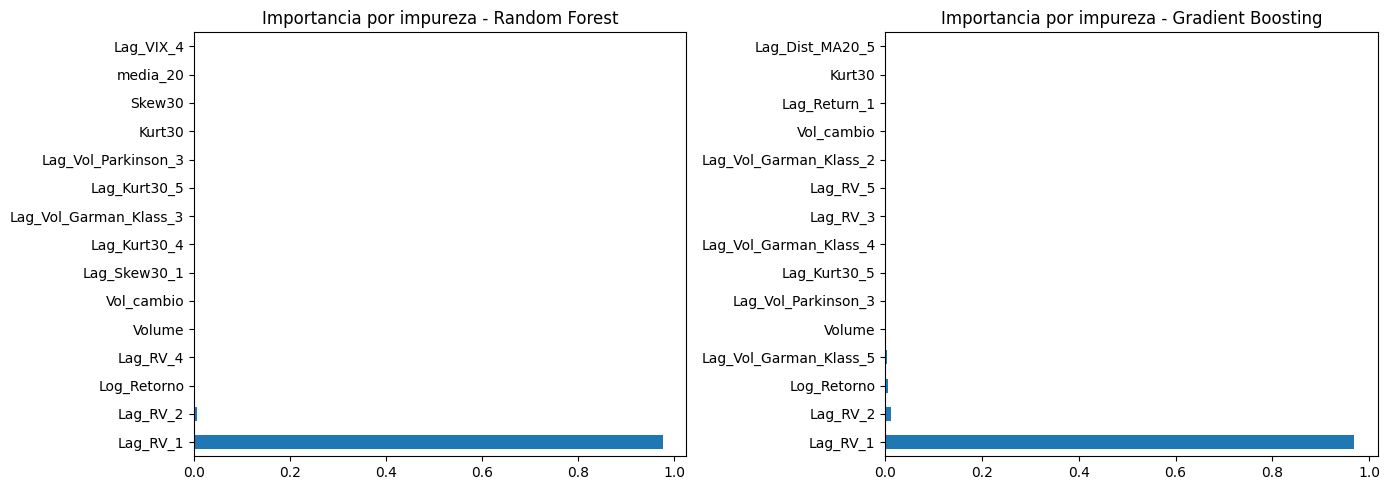

In [50]:
# Gráfico Importancia por impureza: Random Forest y Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14,5))

imp_rf_impurity.head(15).plot(kind="barh",ax=axes[0],title="Importancia por impureza - Random Forest")
imp_gb_impurity.head(15).plot(kind="barh",ax=axes[1],title="Importancia por impureza - Gradient Boosting")

plt.tight_layout()
plt.show()

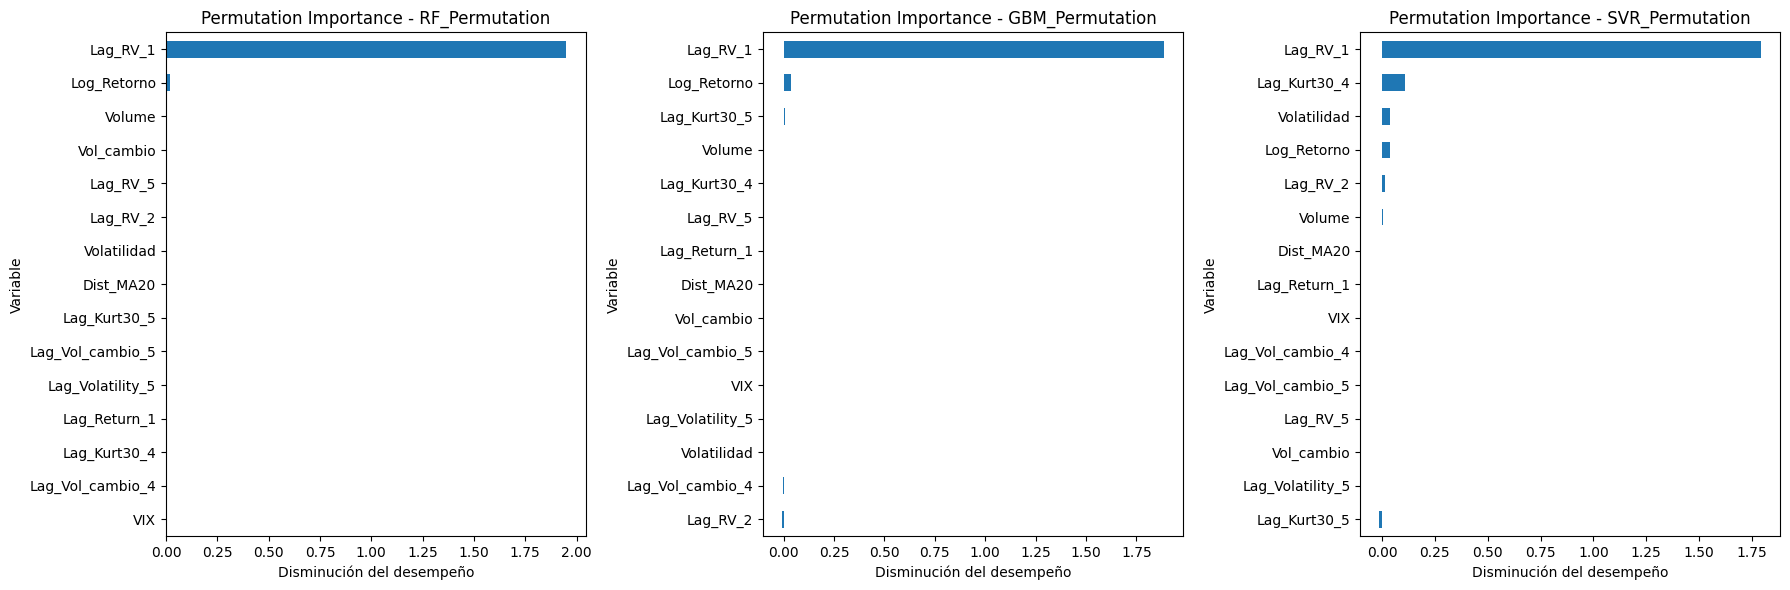

In [57]:
# Gráfico Permutation Importance para los tres modelos

permutation_models = importancias_df[['RF_Permutation', 'GBM_Permutation', 'SVR_Permutation']]

# Seleccionar las 15 variables más importantes según RF
top_features = importancias_df.sort_values(by="RF_Permutation",ascending=False).head(15).index

fig, axes = plt.subplots(1, 3, figsize=(18,6))

for ax, model in zip(axes, permutation_models.columns):
    
    permutation_models.loc[top_features, model].sort_values().plot(kind="barh",ax=ax)
    
    ax.set_title(f"Permutation Importance - {model}")
    ax.set_xlabel("Disminución del desempeño")
    ax.set_ylabel("Variable")

plt.tight_layout()
plt.show()

La importancia de las variables indica que la predicción de la volatilidad está determinada principalmente por la dinámica histórica de la propia serie. En Random Forest, la importancia se distribuye entre varios rezagos de la volatilidad y distintos estimadores realizados, como la volatilidad realizada (RV) y Garman-Klass, lo que refleja un uso más diversificado de la información disponible. En contraste, Gradient Boosting concentra más del 85% de la importancia en Lag_RV_1 y Volatilidad, lo que sugiere que estas variables contienen la mayor parte de la información predictiva. En conjunto, estos resultados son consistentes con la elevada persistencia temporal que caracteriza a la volatilidad de los mercados financieros, donde el comportamiento reciente constituye el principal determinante de la volatilidad futura.

La importancia por permutación revela un patrón consistente entre los tres modelos, evidenciando que la predicción de la volatilidad depende principalmente de la volatilidad actual y del primer rezago de la volatilidad realizada (Lag_RV_1). Si bien Random Forest distribuye la importancia entre un mayor número de rezagos, SVR y, especialmente, Gradient Boosting concentran la mayor parte de su capacidad predictiva en estas dos variables. En contraste, el resto de los predictores presentan una contribución marginal, lo que indica que aportan escasa información adicional una vez incorporada la historia reciente de la volatilidad. Estos resultados refuerzan la evidencia de la elevada persistencia temporal característica de la volatilidad en los mercados financieros.

### 2.5 Evaluación y Comparación de Desempeño


**(a)** Evalúe cada modelo en el conjunto de prueba utilizando las métricas **RMSE, MAE y QLIKE**. Esta última corresponde a la función de pérdida estándar en la literatura de *forecasting* de volatilidad, $\text{QLIKE}=\frac{1}{n}\sum_{t=1}^{n}\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}-\ln\left(\frac{\text{RV}_t}{\hat{\sigma}_t^{2}}\right)-1\right),$ y es más robusta a la asimetría de la distribución de la volatilidad que el RMSE.  

(b) Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

In [ ]:
# Evaluación de modelos con RMSE, MAE y QLIKE

# Definición de la función de pérdida QLIKE
def qlike_loss(y_true, y_pred):
    """
    Calcula la función de pérdida QLIKE.
    y_true: Valores reales de volatilidad (RV_t)
    y_pred: Predicciones del modelo (sigma_hat^2_t)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Evitar divisiones por cero o valores <= 0 en el logaritmo
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, None)
    
    ratio = y_true / y_pred
    loss = np.mean(ratio - np.log(ratio) - 1)
    return loss

# Generar predicciones en el conjunto de prueba para cada modelo
pred_rf  = best_rf.predict(X_test_scaled)
pred_gb  = best_gbr.predict(X_test_scaled)
pred_svr = best_svr.predict(X_test_scaled)

# Función auxiliar para consolidar las 3 métricas
def evaluar_modelo(y_true, y_pred):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    qlike = qlike_loss(y_true, y_pred)
    return rmse, mae, qlike

# Construcción de la tabla de resultados
metricas = {
    'Random Forest': evaluar_modelo(y_test, pred_rf),
    'Gradient Boosting': evaluar_modelo(y_test, pred_gb),
    'SVR': evaluar_modelo(y_test, pred_svr)
}

df_resultados = pd.DataFrame(
    metricas, 
    index=['RMSE', 'MAE', 'QLIKE']
).T

print("=== EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ===")
print(df_resultados.round(6))

=== EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ===
                       RMSE       MAE     QLIKE
Random Forest      0.000944  0.000490  0.001342
Gradient Boosting  0.000914  0.000565  0.001222
SVR                0.001820  0.001425  0.004270


Los resultados evidencian que los modelos de ensamble basados en árboles superan ampliamente a SVR en la predicción de la volatilidad realizada. Gradient Boosting alcanza el menor RMSE y MAE, indicando una mayor precisión en términos de error absoluto, mientras que Random Forest presenta el mejor desempeño según la función QLIKE, métrica especialmente relevante en pronósticos de volatilidad financiera. Por lo tanto, ambos modelos muestran ventajas complementarias, aunque Random Forest podría ser preferible cuando el objetivo principal es minimizar errores relativos en la estimación de la varianza.

**(b)** Grafique la volatilidad observada vs. la volatilidad estimada por cada modelo en el conjunto de prueba, en un mismo panel para facilitar la comparación visual.

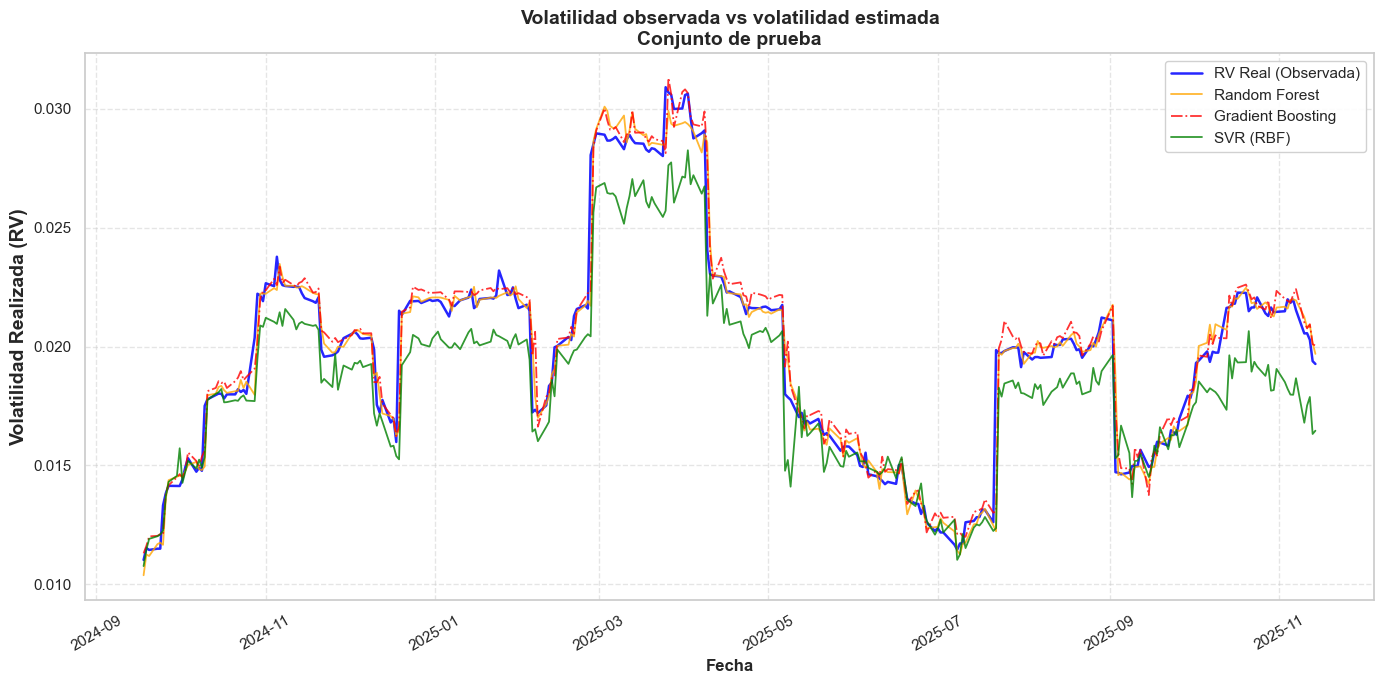

In [61]:
# Gráfico volatilidad observada vs estimada

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Graficar la Volatilidad Real (Observada)
plt.plot(X_test.index, y_test, label='RV Real (Observada)', color='blue', linewidth=1.8, alpha=0.85)

# 2. Graficar las Predicciones de cada Modelo
plt.plot(X_test.index, pred_rf, label='Random Forest', color='orange', linewidth=1.3, linestyle='-', alpha=0.8)
plt.plot(X_test.index, pred_gb, label='Gradient Boosting', color='red', linewidth=1.3, linestyle='-.', alpha=0.8)
plt.plot(X_test.index, pred_svr, label='SVR (RBF)', color='green', linewidth=1.3, linestyle='-', alpha=0.8)

# 3. Personalización del Gráfico
plt.title("Volatilidad observada vs volatilidad estimada\nConjunto de prueba", fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.ylabel('Volatilidad Realizada (RV)', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar rotación de fechas en el eje X para mejorar la lectura
plt.xticks(rotation=30)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### 2.6 Benchmark contra Modelos Econométricos

**(a)** Ajuste modelos GARCH(1,1) y EGARCH(1,1) (vistos en clases) sobre los retornos de la misma acción, y genere pronósticos de volatilidad fuera de muestra alineados temporalmente con el mismo período de prueba usado para los modelos de ML (use un esquema rolling/expanding window explícito y consistente con el usado, si corresponde, en la sección de series de tiempo).

In [62]:
# ==============================================================================
# 1. ALINEACIÓN TEMPORAL Y ESCALAMIENTO
# ==============================================================================
# Extraemos las fechas del conjunto de prueba usado en los modelos de ML
test_index = X_test.index
n_test = len(test_index)

# Serie de retornos logarítmicos alineada con el DataFrame
# Se multiplica por 100 para optimizar la convergencia numérica en la librería 'arch'
returns_series = data.loc[data.index, "Log_Retorno"] * 100

# Posición donde inicia el conjunto de prueba
start_loc = len(returns_series) - n_test

# Arreglos para almacenar las varianzas pronosticadas a 1 paso adelante
var_pred_garch = np.zeros(n_test)
var_pred_egarch = np.zeros(n_test)

# ==============================================================================
# 2. BUCLE EXPANDING WINDOW (1-STEP-AHEAD FORECASTING)
# ==============================================================================
print(f"Iniciando estimación fuera de muestra ({n_test} observaciones)...")

for i in range(n_test):
    # La muestra de entrenamiento se expande hasta t - 1
    train_returns = returns_series.iloc[:start_loc + i]
    
    # --------------------------------------------------------------------------
    # A. Modelo GARCH(1,1)
    # --------------------------------------------------------------------------
    model_garch = arch_model(train_returns, p=1, q=1, vol='GARCH', dist='normal')
    res_garch = model_garch.fit(disp='off')
    
    # Pronóstico de varianza a 1 paso
    f_garch = res_garch.forecast(horizon=1)
    var_pred_garch[i] = f_garch.variance.iloc[-1, 0]
    
    # --------------------------------------------------------------------------
    # B. Modelo EGARCH(1,1)
    # --------------------------------------------------------------------------
    model_egarch = arch_model(train_returns, p=1, q=1, vol='EGARCH', dist='normal')
    res_egarch = model_egarch.fit(disp='off')
    
    # Pronóstico de varianza a 1 paso
    f_egarch = res_egarch.forecast(horizon=1)
    var_pred_egarch[i] = f_egarch.variance.iloc[-1, 0]

# ==============================================================================
# 3. CONVERSIÓN A DESVIACIÓN ESTÁNDAR (ESCALA ORIGINAL DE RV)
# ==============================================================================
# 1. Tomamos raíz cuadrada para pasar de Varianza -> Desviación Estándar.
# 2. Dividimos entre 100 para revertir el rescalamiento inicial de los retornos.

pred_garch_rv = pd.Series(np.sqrt(var_pred_garch) / 100, index=test_index)
pred_egarch_rv = pd.Series(np.sqrt(var_pred_egarch) / 100, index=test_index)

print("¡Proceso finalizado! Pronósticos econométricos listos.")

Iniciando estimación fuera de muestra (292 observaciones)...
¡Proceso finalizado! Pronósticos econométricos listos.


**(b)** Compare RMSE, MAE y QLIKE de los cuatro-cinco modelos (RF, SVR, [GBM], GARCH, EGARCH) en una tabla resumen ordenada por desempeño.

In [63]:
# Definición de la función QLIKE
def qlike_loss(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, None)
    ratio = y_true / y_pred
    return np.mean(ratio - np.log(ratio) - 1)

# Función para calcular todas las métricas de un modelo
def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    qlike = qlike_loss(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'QLIKE': qlike}

# Diccionario con todas las predicciones sobre el conjunto de prueba
diccionario_predicciones = {
    'Random Forest': pred_rf,
    'Gradient Boosting (GBM)': pred_gb,
    'SVR': pred_svr,
    'GARCH(1,1)': pred_garch_rv,
    'EGARCH(1,1)': pred_egarch_rv
}

# Construcción de la tabla de resultados
resultados = []
for nombre_modelo, y_pred in diccionario_predicciones.items():
    m = calcular_metricas(y_test, y_pred)
    m['Modelo'] = nombre_modelo
    resultados.append(m)

# Crear DataFrame y reordenar columnas
df_resumen = pd.DataFrame(resultados)[['Modelo', 'QLIKE', 'RMSE', 'MAE']]

# Ordenar por la métrica principal en literatura de volatilidad (QLIKE ascendente)
df_resumen = df_resumen.sort_values(by='QLIKE', ascending=True).reset_index(drop=True)

# Imprimir tabla formateada
print("=== Tabla comparativa de desempeño en el conjunto de prueba ===")
print(df_resumen.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

=== Tabla comparativa de desempeño en el conjunto de prueba ===
                 Modelo    QLIKE     RMSE      MAE
Gradient Boosting (GBM) 0.001222 0.000914 0.000565
          Random Forest 0.001342 0.000944 0.000490
                    SVR 0.004270 0.001820 0.001425
            EGARCH(1,1) 0.030386 0.004822 0.004238
             GARCH(1,1) 0.032855 0.005126 0.004428


**(c)** Aplique el test de Diebold-Mariano para determinar si la diferencia de desempeño entre el mejor modelo de ML y el mejor modelo GARCH/EGARCH es estadísticamente significativa, o si podría deberse a ruido muestral.

In [70]:
def diebold_mariano_test(y_true, y_pred1, y_pred2, h=1):
    """
    Realiza el test de Diebold-Mariano usando la función de pérdida QLIKE.
    
    y_true: Volatilidad real observada
    y_pred1: Predicciones del Modelo 1 (ej. Mejor ML)
    y_pred2: Predicciones del Modelo 2 (ej. Mejor EGARCH/GARCH)
    h: Horizonte de pronóstico (por defecto 1)
    """
    y_true = np.array(y_true)
    y_pred1 = np.array(y_pred1)
    y_pred2 = np.array(y_pred2)
    eps = 1e-8
    
    # 1. Calcular pérdidas QLIKE individuales para cada punto en el tiempo
    loss1 = (y_true / np.clip(y_pred1, eps, None)) - np.log((y_true / np.clip(y_pred1, eps, None))) - 1
    loss2 = (y_true / np.clip(y_pred2, eps, None)) - np.log((y_true / np.clip(y_pred2, eps, None))) - 1
    
    # 2. Diferencial de pérdida: d_t = Loss(Modelo 1) - Loss(Modelo 2)
    d = loss1 - loss2
    d_bar = np.mean(d)
    T = len(d)
    
    # 3. Estimación de varianza con autocovarianza (Ajuste Newey-West / HAC)
    # Autocovarianza a lag 0
    gamma_0 = np.var(d, ddof=0)
    
    # Suma de autocovarianzas ponderadas hasta el lag (h - 1)
    gamma_sum = 0
    for k in range(1, h):
        gamma_k = np.cov(d[:-k], d[k:], ddof=0)[0, 1]
        weight = 1 - (k / h) # Ponderador de Bartlett
        gamma_sum += weight * gamma_k
        
    var_d = (gamma_0 + 2 * gamma_sum) / T
    
    # 4. Estadístico DM (distribuido asintóticamente como N(0,1))
    DM_stat = d_bar / np.sqrt(var_d)
    
    # Corrección para muestras finitas de Harvey, Leybourne y Newbold (HLN)
    HLN_factor = np.sqrt((T + 1 - 2*h + (h/T)*(h - 1)) / T)
    DM_stat_corrected = DM_stat * HLN_factor
    
    # p-valor bilateral (two-tailed test)
    p_value = 2 * (1 - stats.norm.cdf(np.abs(DM_stat_corrected)))
    
    return DM_stat_corrected, p_value

In [71]:
# APLICACIÓN DEL TEST ENTRE Gradient Boosting vs GARCH

dm_stat, p_val = diebold_mariano_test(y_test, pred_gb, pred_garch_rv, h=1)

print("=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs GARCH ===")
print(f"Estadístico DM: {dm_stat:.4f}")
print(f"p-valor:        {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.")
    print("La diferencia de desempeño entre Gradient Boosting y GARCH ES estadísticamente significativa.")
else:
    print("\nConclusión: NO se rechaza la hipótesis nula ($H_0$).")
    print("La diferencia de desempeño podría deberse únicamente a ruido muestral.")

=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs GARCH ===
Estadístico DM: -17.4600
p-valor:        0.000000

Conclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.
La diferencia de desempeño entre Gradient Boosting y GARCH ES estadísticamente significativa.


In [72]:
# APLICACIÓN DEL TEST ENTRE Gradient Boosting vs EGARCH

dm_stat, p_val = diebold_mariano_test(y_test, pred_gb, pred_egarch_rv, h=1)

print("=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs EGARCH ===")
print(f"Estadístico DM: {dm_stat:.4f}")
print(f"p-valor:        {p_val:.6f}")

if p_val < 0.05:
    print("\nConclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.")
    print("La diferencia de desempeño entre Gradient Boosting y EGARCH ES estadísticamente significativa.")
else:
    print("\nConclusión: NO se rechaza la hipótesis nula ($H_0$).")
    print("La diferencia de desempeño podría deberse únicamente a ruido muestral.")

=== TEST DE DIEBOLD-MARIANO (PÉRDIDA QLIKE) Gradient Boosting vs EGARCH ===
Estadístico DM: -17.9259
p-valor:        0.000000

Conclusión: Se RECHAZA la hipótesis nula ($H_0$) con un 95% de confianza.
La diferencia de desempeño entre Gradient Boosting y EGARCH ES estadísticamente significativa.


El test de Diebold-Mariano evalúa la hipótesis nula:

$$H_0: E(d_t) = 0$$

donde $d_t$ representa la diferencia entre las pérdidas de pronóstico de ambos modelos utilizando la función QLIKE.

En ambos casos se obtiene un **p-value igual a 0**, por lo que se rechaza la hipótesis nula al 5% de nivel de significancia. Esto indica que la diferencia de desempeño entre **Gradient Boosting** y los modelos **GARCH/EGARCH** es estadísticamente significativa y no puede atribuirse solamente a ruido muestral.

El estadístico $DM$ es negativo en ambas comparaciones:

* $DM_{\text{GBM}-\text{GARCH}} = -17.4600$
* $DM_{\text{GBM}-\text{EGARCH}} = -17.9259$

Dado que la diferencia se definió como:

$$d_t = L_{\text{GBM},t} - L_{\text{GARCH},t}$$

un valor negativo implica que la pérdida promedio del modelo **Gradient Boosting** es menor que la del modelo **GARCH/EGARCH**. Por lo tanto, el signo del estadístico confirma que **GBM presenta un mejor desempeño predictivo**.

### 2.7 Diagnóstico de Errores

Para el modelo ganador (según 2.6b), analice los errores de predicción **$(\text{RV}_t - \hat{\text{RV}}_t)$** en el conjunto de prueba: grafíquelos en el tiempo, evalúe si están correlacionados serialmente (ACF) y si su magnitud se relaciona con períodos de alta volatilidad de mercado (por ejemplo, marcando visualmente eventos de estrés conocidos dentro de su ventana de prueba, si los hay).

In [73]:
# Error de predicción

errores = y_test - pred_gb  # RV_t - RV_hat_t

# Crear un DataFrame
df_errores = pd.DataFrame({
    'RV_real': y_test,
    'RV_pred': pred_gb,
    'Error': errores,
    'Error_Absoluto': np.abs(errores)
}, index=X_test.index)

**Periodo de estrés conjunto de prueba** : Para Google entre 2018-2025, un evento dentro del conjunto de prueba es:

Abril 2025: aumento de volatilidad por anuncios arancelarios y tensiones comerciales.

<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jeloy\AppData\Local\Temp\ipykernel_14136\2922925344.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(df_errores.index, df_errores['Error'], color='blue', linewidth=1.2, label='Error ($RV_t - \hat{RV}_t$)')
C:\Users\jeloy\AppData\Local\Temp\ipykernel_14136\2922925344.py:20: SyntaxWarning: invalid escape sequence '\h'
  plt.title('Errores de Predicción en el Tiempo ($RV_t - \hat{RV}_t$)', fontsize=14, fontweight='bold')


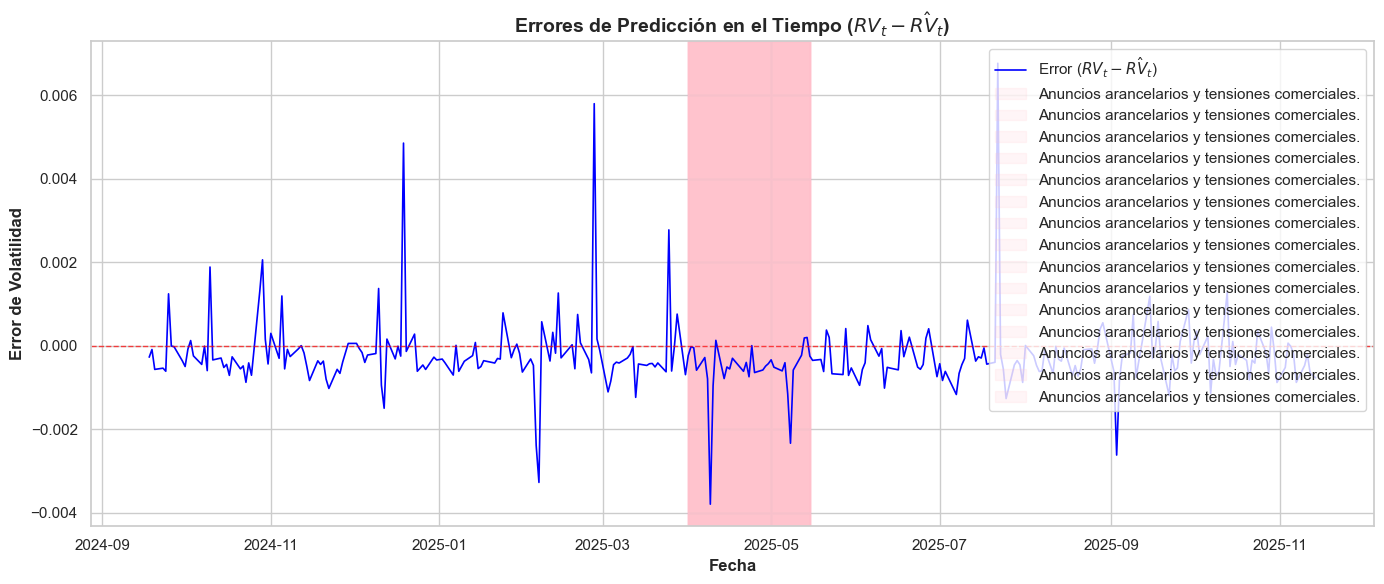

In [76]:
# Gráfico de errores en el tiempo y eventos de estrés
# ==============================================================================
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(df_errores.index, df_errores['Error'], color='blue', linewidth=1.2, label='Error ($RV_t - \hat{RV}_t$)')
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

# --- Identificación / Sombreado de Eventos de Estrés ---
# (Ejemplo: Identificar los picos más altos del 5% superior de volatilidad real)
umbral_pico = df_errores['RV_real'].quantile(0.95)
fechas_picos = df_errores[df_errores['RV_real'] >= umbral_pico].index

for fecha in fechas_picos:
    plt.axvspan(pd.Timestamp('2025-04-01'), pd.Timestamp('2025-05-15'), color='pink', alpha=0.15, label='Anuncios arancelarios y tensiones comerciales.')

# Si tienes un evento histórico específico dentro de tu ventana de test (ej. Marzo 2020), puedes remarcarlo:
# plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-04-15'), color='red', alpha=0.15, label='Período de Estrés (COVID-19)')

plt.title('Errores de Predicción en el Tiempo ($RV_t - \hat{RV}_t$)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12, fontweight='bold')
plt.ylabel('Error de Volatilidad', fontsize=12, fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Según la imagen no existe autocorrelación significativa, los errores se comportan aproximadamente como ruido blanco por lo que el modelo captura adecuadamente la dinámica temporal.

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
C:\Users\jeloy\AppData\Local\Temp\ipykernel_14136\2465127790.py:15: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_ylabel('Error Absoluto (|\hat{e}_t|)', fontsize=10)


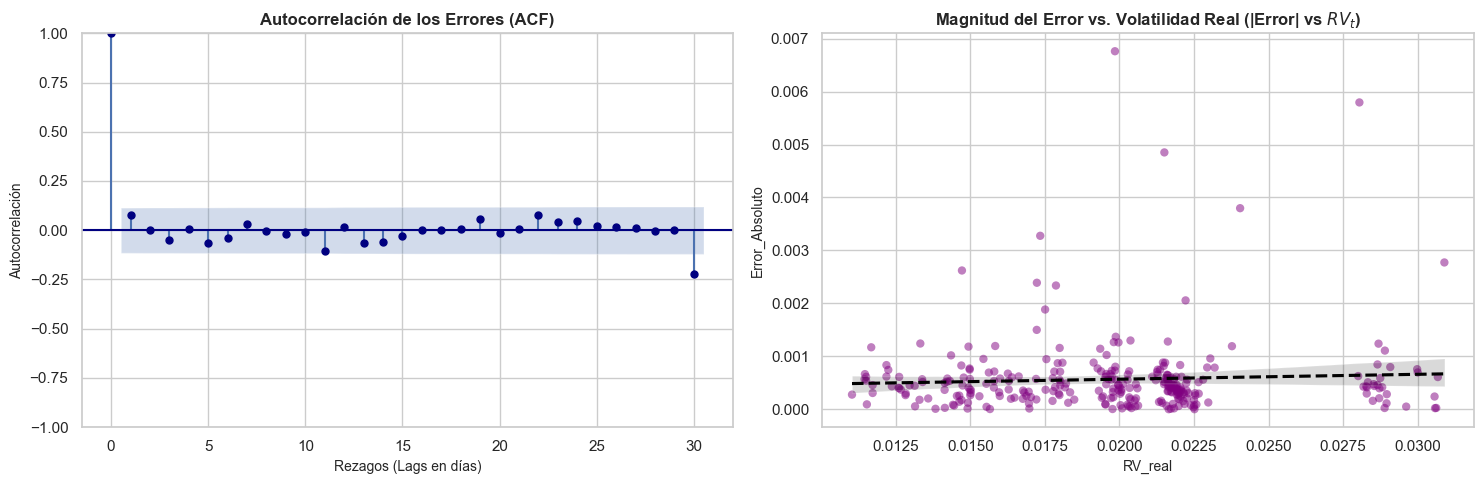

In [82]:
# 3. GRÁFICO 2: AUTOCORRELACIÓN DE ERRORES (ACF) Y RELACIÓN CON LA VOLATILIDAD
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot A: Función de Autocorrelación (ACF) de los errores
plot_acf(df_errores['Error'], lags=30, ax=axes[0], alpha=0.05, color='navy')
axes[0].set_title('Autocorrelación de los Errores (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rezagos (Lags en días)', fontsize=10)
axes[0].set_ylabel('Autocorrelación', fontsize=10)

# Subplot B: Magnitud del Error vs Nivel de Volatilidad Real
axes[1].scatter(df_errores['RV_real'], df_errores['Error_Absoluto'], color='purple', alpha=0.5, edgecolors='none')
axes[1].set_title('Magnitud del Error vs. Volatilidad Real (|Error| vs $RV_t$)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Volatilidad Real ($RV_t$)', fontsize=10)
axes[1].set_ylabel('Error Absoluto (|\hat{e}_t|)', fontsize=10)

# Línea de tendencia lineal para evidenciar heterocedasticidad
sns.regplot(x='RV_real', y='Error_Absoluto', data=df_errores, ax=axes[1], scatter=False, color='black', line_kws={'linestyle':'--'})

plt.tight_layout()
plt.show()

Los errores de predicción del modelo Gradient Boosting se definieron como **$(\text{RV}_t - \hat{\text{RV}}_t)$**. La serie de errores fluctúa alrededor de cero, sin evidenciar sesgos sistemáticos de sobreestimación o subestimación. Además, la ACF no muestra autocorrelaciones significativas, lo que indica que los errores se comportan aproximadamente como ruido blanco.

El gráfico de la magnitud del error evidencia presencia de heterocedasticidad en los errores, ya que la dispersión aumenta a medida que crece la volatilidad realizada. En períodos de baja volatilidad, los errores son pequeños y el modelo presenta un comportamiento estable. Sin embargo, en escenarios de mayor volatilidad aparecen errores más elevados y valores atípicos, indicando una menor precisión durante episodios de estrés de mercado.

Además, la pendiente levemente positiva de la línea de tendencia sugiere una relación directa entre la volatilidad y el error de predicción: a mayores niveles de volatilidad, mayor es la magnitud esperada del error.

### 2.8 Discusión Final

Responda de forma breve y argumentada: 


**1.** ¿El mejor modelo de machine learning supera de forma estadísticamente significativa a los benchmarks GARCH/EGARCH? Si no es así, ¿qué tan justificable es, en la práctica, preferir un modelo de caja negra sobre uno econométrico interpretable con desempeño similar?

El modelo Gradient Boosting superó significativamente a GARCH(1,1) y EGARCH(1,1), según el test de Diebold-Mariano, con p-values iguales a cero. Esto confirma que la diferencia de desempeño no se explica por variaciones aleatorias de la muestra. Sin embargo, si ambos enfoques tuvieran resultados similares, la elección dependería del propósito del análisis: los modelos GARCH ofrecen mayor interpretación económica de la volatilidad, mientras que los modelos de ML tienen ventaja al capturar relaciones no lineales y patrones más complejos en los datos.

**2.** ¿Qué variables resultaron más relevantes según la importancia de features, y es consistente con lo que un modelo GARCH asume implícitamente (que el mejor predictor de la volatilidad futura es la volatilidad/los choques pasados)?

Las variables con mayor importancia fueron principalmente los rezagos de la volatilidad realizada y de los retornos históricos, lo que evidencia que la información pasada es fundamental para anticipar la volatilidad futura. Este resultado es coherente con la idea detrás de los modelos GARCH, que explican la volatilidad actual a partir de su comportamiento pasado y de los shocks previos. No obstante, los modelos de ML presentan la ventaja de identificar patrones no lineales y relaciones complejas entre múltiples variables sin requerir una especificación paramétrica predeterminada.

**3.** Mencione al menos dos limitaciones del enfoque de ML utilizado para pronóstico de volatilidad financiera (por ejemplo, incapacidad de extrapolar fuera del rango de entrenamiento, ausencia de una dinámica de reversión a la media explícita, riesgo de sobreajuste con el número de features/rezagos utilizados) y cómo las abordaría en una extensión futura (por ejemplo, modelos híbridos ML-GARCH, LSTM, o ensemble de ambos enfoques)

Una limitación del enfoque de machine learning es su menor capacidad para predecir episodios extremos de volatilidad que no fueron observados durante el entrenamiento, debido a que basa sus estimaciones en patrones históricos. Además, la incorporación de un gran número de rezagos puede aumentar la complejidad del modelo y favorecer el sobreajuste, reduciendo su desempeño fuera de muestra.

Como posibles mejoras futuras, se podría implementar un modelo híbrido ML-GARCH, donde GARCH capture la persistencia y dinámica temporal de la volatilidad, mientras que ML identifique relaciones no lineales. También sería posible explorar modelos como LSTM o combinaciones de distintos modelos (ensembles) para aumentar la robustez de los pronósticos en períodos de alta incertidumbre.